In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv('heart.csv')
df.head()
df.shape

(1025, 14)

In [3]:
X=df.drop('target', axis=1)
y=df['target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1025, 13)
Target Shape: (1025,)


In [4]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 717
Testing samples: 308


In [5]:
model=DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

train_accuracy=accuracy_score(y_train, y_train_pred)
test_accuracy=accuracy_score(y_test, y_test_pred)

print("Training Accuracy", train_accuracy)
print("Test Accuracy", test_accuracy)

Training Accuracy 1.0
Test Accuracy 0.9707792207792207


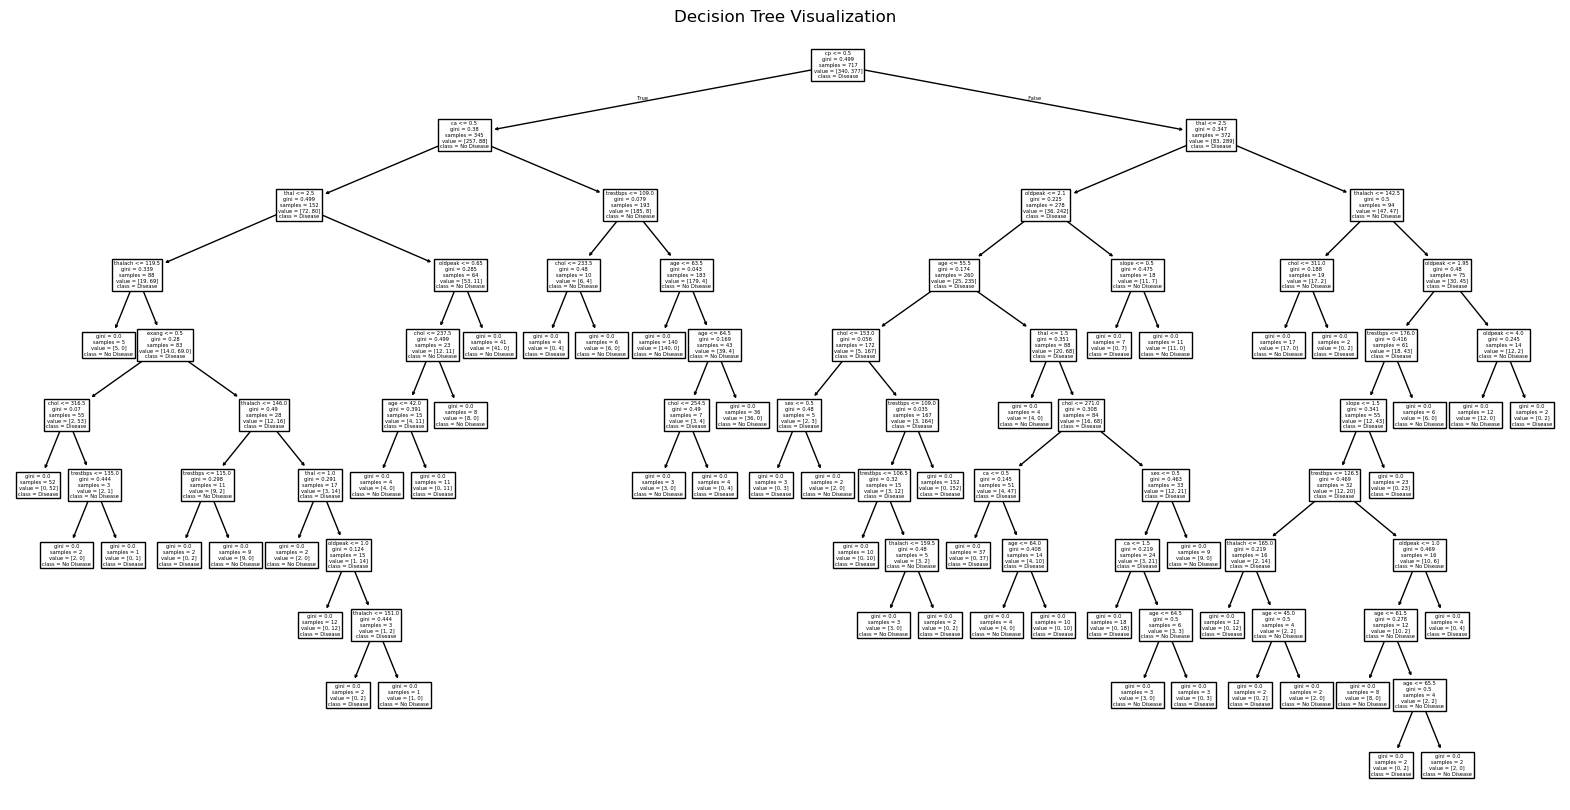

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=False)
plt.title("Decision Tree Visualization")
plt.show()

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [9]:
cm=confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[159   0]
 [  9 140]]


In [10]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



In [11]:
y_prob=model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds=roc_curve(y_test, y_prob)

auc_score=roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9697986577181208


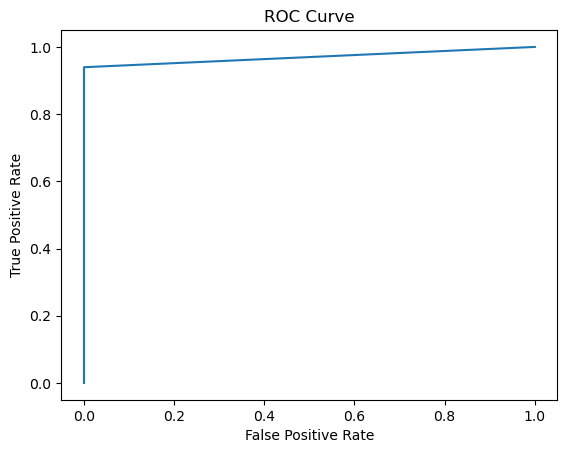

In [12]:
plt.figure()
plt.plot(fpr ,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [13]:
depths=range(1, 21)

train_acc=[]
test_acc=[]

for d in depths:
    model=DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

print("Done")

Done


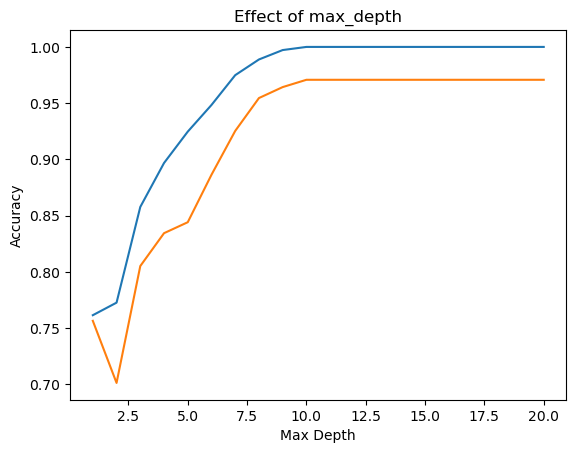

In [14]:
plt.figure()
plt.plot(depths, train_acc)
plt.plot(depths, test_acc)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth")
plt.show()

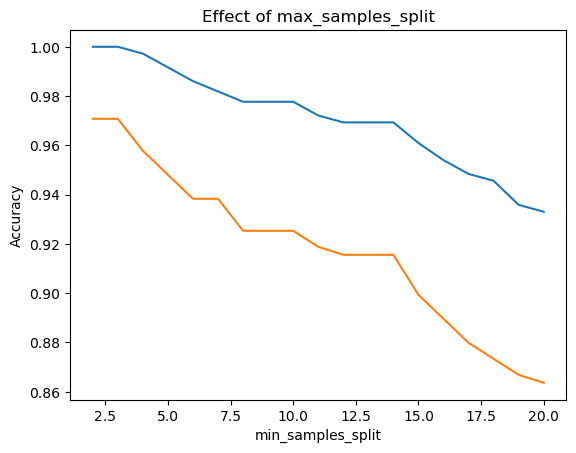

In [16]:
splits=range(2, 21)

train_acc=[]
test_acc=[]

for s in splits:
    model=DecisionTreeClassifier(min_samples_split=s, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(splits, train_acc)
plt.plot(splits, test_acc)
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.title("Effect of max_samples_split")
plt.show()

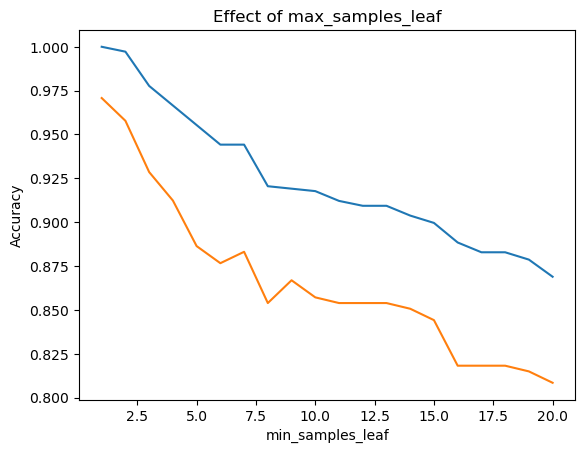

In [17]:
leaves=range(1, 21)

train_acc=[]
test_acc=[]

for l in leaves:
    model=DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(leaves, train_acc)
plt.plot(leaves, test_acc)
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Effect of max_samples_leaf")
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
param_grid={
    'max_depth': range(1, 21),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 11)
}

In [20]:
grid=GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9720862470862471


In [21]:
best_model=grid.best_estimator_

train_acc=accuracy_score(y_train, best_model.predict(X_train))
test_acc=accuracy_score(y_test, best_model.predict(X_test))

print("Training Accuracy (Best Model):", train_acc)
print("Testing Accuracy (Best Model):", test_acc)

Training Accuracy (Best Model): 1.0
Testing Accuracy (Best Model): 0.9707792207792207


In [23]:
y_pred=best_model.predict(X_test)

results=X_test.copy()
results['Actual']=y_test
results['Predicted']=y_pred

misclassified=results[results['Actual']!= results['Predicted']]
correctly_classified=results[results['Actual']== results['Predicted']]

print("Total Test Samples:", len(results))
print("Correctly Classified:", len(correctly_classified))
print("Misclassified", len(misclassified))

Total Test Samples: 308
Correctly Classified: 299
Misclassified 9


In [24]:
misclassified.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted
96,57,0,0,128,303,0,0,159,0,0.0,2,1,2,1,0
420,57,0,0,128,303,0,0,159,0,0.0,2,1,2,1,0
490,57,0,0,128,303,0,0,159,0,0.0,2,1,2,1,0
603,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1,0
494,51,1,2,125,245,1,0,166,0,2.4,1,0,2,1,0


In [25]:
mis_mean=misclassified.drop(['Actual', 'Predicted'], axis=1).mean()
correct_mean=correctly_classified.drop(['Actual', 'Predicted'], axis=1).mean()

comparison=pd.DataFrame({
    "Misclassified Mean": mis_mean,
    "Correct Mean": correct_mean
})

comparison

,Misclassified Mean,Correct Mean
age,57.000000,54.571906
sex,0.333333,0.678930
cp,1.000000,0.876254
trestbps,131.000000,131.063545
chol,247.666667,249.772575
fbs,0.333333,0.130435
restecg,0.333333,0.565217
thalach,168.000000,146.234114
exang,0.000000,0.351171
oldpeak,0.800000,1.191639


In [26]:
key_features=['age', 'cp', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

comparison.loc[key_features]

,Misclassified Mean,Correct Mean
age,57.000000,54.571906
cp,1.000000,0.876254
chol,247.666667,249.772575
thalach,168.000000,146.234114
oldpeak,0.800000,1.191639
ca,1.000000,0.709030
thal,2.000000,2.324415


In [27]:
class_counts=y.value_counts()

print("Class Distribution")
print(class_counts)

Class Distribution
target
1    526
0    499
Name: count, dtype: int64


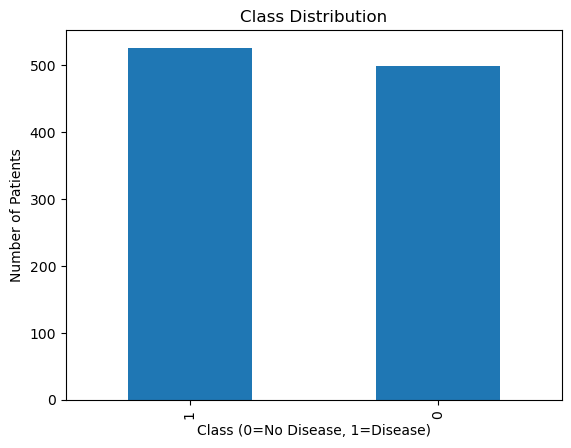

In [28]:
plt.figure()
class_counts.plot(kind='bar')
plt.xlabel("Class (0=No Disease, 1=Disease)")
plt.ylabel("Number of Patients")
plt.title("Class Distribution")
plt.show()

In [29]:
class_percent=y.value_counts(normalize=True)*100
print("Class Percentage:")
print(class_percent)

Class Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64
